
## A. Cel zadania

Głównym celem zadania było zaprojektowanie, wytrenowanie i zoptymalizowanie konwolucyjnej sieci neuronowej (CNN) do rozpoznawania odręcznie pisanych cyfr ze zbioru MNIST. Dodatkowo, projekt obejmował empiryczne zbadanie wpływu różnych hiperparametrów (liczba filtrów, liczba neuronów, rozmiar wsadu – batch size) na jakość modelu, a ostatecznie ewaluację najlepszej sieci na własnym zbiorze zdjęć i porównanie jej skuteczności z klasyczną, wielowarstwową siecią perceptronową (MLP).

## B. Wstęp teoretyczny

W projekcie wykorzystano środowisko Python wraz z następującymi bibliotekami:

* **TensorFlow / Keras**: do budowy, kompilacji i uczenia architektur sieci neuronowych (CNN oraz MLP).
* **NumPy**: do operacji na macierzach.
* **OpenCV (cv2)**: do wczytywania i wstępnego przetwarzania własnych zdjęć testowych.
* **Matplotlib i Seaborn**: do wizualizacji krzywych uczenia, macierzy pomyłek oraz wyników predykcji.

Dane treningowe i testowe pochodziły z bazy **MNIST**. Są to obrazy w skali szarości o rozdzielczości 28x28 pikseli. Przed podaniem ich na wejście sieci, wartości pikseli zostały znormalizowane do zakresu $[0, 1]$, co znacząco ułatwia i przyspiesza zbieżność procesu optymalizacji.

## 1. Metodologia i Architektura Sieci Konwolucyjnej (CNN)

### 1.1. Reprezentacja wejścia i warstwa konwolucyjna (Conv2D)

Sieć konwolucyjna analizuje obraz jako dwuwymiarową macierz pikseli (w tym przypadku z jednym kanałem koloru). Kluczowym elementem sieci jest warstwa splotowa (Conv2D), w której specjalne filtry "przesuwają się" po obrazie wejściowym, aby wyodrębnić lokalne cechy (np. krawędzie).

Operację splotu można opisać wzorem:


$$M(u, v) = \sum_{i=-a}^{a} \sum_{j=-b}^{b} K(i, j) \cdot I(u+i, v+j)$$


gdzie:

* $M(u, v)$ to wartość nowo wygenerowanej mapy cech w punkcie $(u, v)$,
* $I$ to macierz obrazu wejściowego (lub poprzedniej mapy cech),
* $K$ to macierz wag filtru (jądra) o rozmiarach określonych przez parametry $a$ i $b$.

W najlepszym wariancie modelu zastosowano macierze filtrów o rozmiarze 3x3.

### 1.2. Nieliniowa funkcja aktywacji (ReLU)

Bezpośrednio po operacji splotu, na wynik nakładana jest nieliniowa funkcja aktywacji **ReLU** (Rectified Linear Unit). Jej zadaniem jest zerowanie wartości ujemnych, co wprowadza nieliniowość do modelu i pozwala sieci uczyć się bardziej złożonych wzorców.
Wzór na funkcję ReLU:


$$A(z) = \max(0, z)$$


gdzie $z$ to wynik operacji liniowej (np. splotu) dla danego neuronu.

### 1.3. Warstwa redukująca wymiarowość (MaxPooling2D)

Kolejnym krokiem w architekturze jest warstwa MaxPooling2D. Jej celem jest zmniejszenie rozdzielczości przestrzennej mapy cech poprzez wybieranie tylko największej wartości z zadanego okna. Dzięki temu sieć staje się mniej czuła na drobne przesunięcia obiektów na obrazie, a także drastycznie spada liczba parametrów w kolejnych warstwach.

### 1.4. Klasyfikator (Flatten i Dense)

Po wyodrębnieniu cech przez sekcję konwolucyjną, wielowymiarowe struktury danych są "spłaszczane" (warstwa Flatten) do jednowymiarowego wektora. Następnie trafiają do w pełni połączonych warstw gęstych (Dense). Ostatnia warstwa posiada dokładnie 10 neuronów (odpowiadających 10 cyfrom) i wykorzystuje funkcję aktywacji **Softmax**. Zamienia ona wyjścia z neuronów (logity) na rozkład prawdopodobieństwa:


$$P_c = \frac{e^{v_c}}{\sum_{k=1}^{C} e^{v_k}}$$


gdzie $P_c$ to prawdopodobieństwo przynależności obiektu do klasy $c$, a $v$ to wartości wyjściowe z warstwy ukrytej przed aktywacją dla $C$ klas.

## 2. Proces optymalizacji i funkcja straty

Celem treningu jest zminimalizowanie błędu popełnianego przez sieć. Jako funkcję straty (loss function) w kodzie użyto **Sparse Categorical Crossentropy** (odmianę entropii krzyżowej dostosowaną do etykiet podanych jako liczby całkowite). Entropię krzyżową wyraża wzór:


$$E = - \sum_{i=1}^{N} d_i \ln(o_i)$$


gdzie $d_i$ to wartość oczekiwana (1 dla prawidłowej klasy, 0 dla pozostałych), a $o_i$ to prawdopodobieństwo zwrócone przez sieć (wyjście z funkcji Softmax).

Proces minimalizacji błędu jest realizowany z wykorzystaniem algorytmu optymalizacyjnego **Adam**, który dynamicznie dostosowuje współczynnik uczenia na podstawie wyliczanych gradientów propagowanych wstecznie.

## 3. Klasyczna Architektura MLP (Multilayer Perceptron)

W ramach eksperymentu zaimplementowano również klasyczną sieć MLP. Model ten bezpośrednio spłaszcza obraz wejściowy z macierzy 28x28 na wektor 784 elementów, ignorując całkowicie lokalną strukturę obrazu (zależności między sąsiednimi pikselami). Struktura zawierała dwie ukryte warstwy gęste (128 i 64 neurony) z aktywacją ReLU. Choć model ten działa szybko, jego architektura wymusza uczenie się globalnych wzorców dla całej przestrzeni obrazu, przez co jest znacznie bardziej podatny na błędy w przypadku własnych, odręcznych rysunków, w których cyfra nie jest idealnie wyśrodkowana.

## 4. Metryki i wizualizacja wyników ewaluacji

Analiza działania modeli opierała się na kilku metrykach i wizualizacjach:

1. **Dokładność (Accuracy)** – odsetek poprawnie sklasyfikowanych obrazów, monitorowany zarówno dla zbioru treningowego, jak i walidacyjnego. Pozwoliło to wybrać optymalny zestaw hiperparametrów w pętli eksperymentów.
2. **Krzywe uczenia** – przebiegi funkcji straty i dokładności w kolejnych epokach, dające obraz tego, czy model uczy się stabilnie i czy nie dochodzi do zjawiska przeuczenia (overfittingu).
3. **Macierz pomyłek (Confusion Matrix)** – kwadratowa macierz, w której wiersze reprezentują prawdziwe klasy, a kolumny klasy przewidziane przez sieć. Wygenerowana przy pomocy biblioteki *Seaborn*, pozwoliła na wizualne zidentyfikowanie, które cyfry model najczęściej ze sobą myli (np. 3 i 8).
4. **Wizualizacja na zewnętrznych danych** – autorskie zdjęcia cyfr zostały wczytane za pomocą *OpenCV*, gdzie zastosowano odwrócenie barw (cyfra biała na czarnym tle) w celu dopasowania dystrybucji do bazy MNIST. Predykcje CNN oraz MLP zostały przedstawione na obok leżących wykresach słupkowych (bar plot), wyraźnie obnażając różnice w pewności decyzyjnej (prawdopodobieństwach) między strukturą hierarchiczną (CNN), a płaską (MLP).

##Zadanie 1

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import cv2
import keras_tuner as kt

nr_gr = 5.1
tf.random.set_seed(nr_gr)

## Zadanie 2

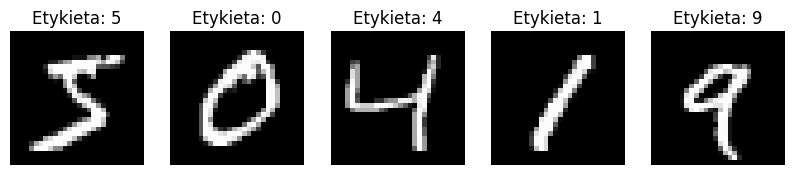

In [8]:
# Wczytanie danych MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalizacja
x_train = x_train / 255.0
x_test = x_test / 255.0

# Wyświetlenie 5 przykładowych obrazów cyfr z zestawu treningowego
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Etykieta: {y_train[i]}")
    plt.axis('off')
plt.show()

## Zadanie 3

In [9]:
import tensorflow as tf

x_train_cnn = x_train.reshape(-1, 28, 28, 1)

eksperymenty = [
    {"nazwa": "Model 1", "filtry": 16, "neurony": 32, "batch": 32},
    {"nazwa": "Model 2", "filtry": 32, "neurony": 32, "batch": 32},
    {"nazwa": "Model 3", "filtry": 32, "neurony": 64, "batch": 64},
    {"nazwa": "Model 4", "filtry": 32, "neurony": 64, "batch": 128},
    {"nazwa": "Model 5", "filtry": 64, "neurony": 128, "batch": 128}
]

najlepsza_dokladnosc = 0
najlepszy_model = None
najlepsza_historia = None

for param in eksperymenty:
    print(f"Trenowanie: {param['nazwa']} (Filtry={param['filtry']}, Neurony={param['neurony']}, Batch={param['batch']})...")

    model_temp = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(param['filtry'], (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(param['neurony'], activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model_temp.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Uczenie modelu
    history_temp = model_temp.fit(x_train_cnn, y_train,
                        epochs=3,
                        batch_size=param['batch'],
                        validation_split=0.2,
                        verbose=0)

    # Pobieramy wynik z ostatniej epoki na zbiorze walidacyjnym
    val_acc = history_temp.history['val_accuracy'][-1]
    param['wynik_acc'] = val_acc

    print(f"Dokładność: {val_acc:.4f}\n")

    # Zapisujemy najlepszy model
    if val_acc > najlepsza_dokladnosc:
        najlepsza_dokladnosc = val_acc
        najlepszy_model = model_temp
        najlepsza_historia = history_temp

# Wyświetlenie podsumowania
print("PODSUMOWANIE 5 EKSPERYMENTÓW:")
for param in eksperymenty:
    print(f"{param['nazwa']}: Dokładność = {param['wynik_acc']:.4f}")

print(f"Najlepszy: Model z dokładnością {najlepsza_dokladnosc:.4f}")
model = najlepszy_model
history = najlepsza_historia

Trenowanie: Model 1 (Filtry=16, Neurony=32, Batch=32)...
Dokładność: 0.9819

Trenowanie: Model 2 (Filtry=32, Neurony=32, Batch=32)...
Dokładność: 0.9814

Trenowanie: Model 3 (Filtry=32, Neurony=64, Batch=64)...
Dokładność: 0.9836

Trenowanie: Model 4 (Filtry=32, Neurony=64, Batch=128)...
Dokładność: 0.9825

Trenowanie: Model 5 (Filtry=64, Neurony=128, Batch=128)...
Dokładność: 0.9838

PODSUMOWANIE 5 EKSPERYMENTÓW:
Model 1: Dokładność = 0.9819
Model 2: Dokładność = 0.9814
Model 3: Dokładność = 0.9836
Model 4: Dokładność = 0.9825
Model 5: Dokładność = 0.9838
Najlepszy: Model z dokładnością 0.9838


Wszystkie testowane konfiguracje osiągnęły bardzo wysoką dokładność na zbiorze walidacyjnym (powyżej 98%). Wynika to ze specyfiki zbioru MNIST, w którym nawet stosunkowo proste architektury sieci konwolucyjnych doskonale radzą sobie z ekstrakcją cech i prawidłową klasyfikacją.

## Zadanie 4

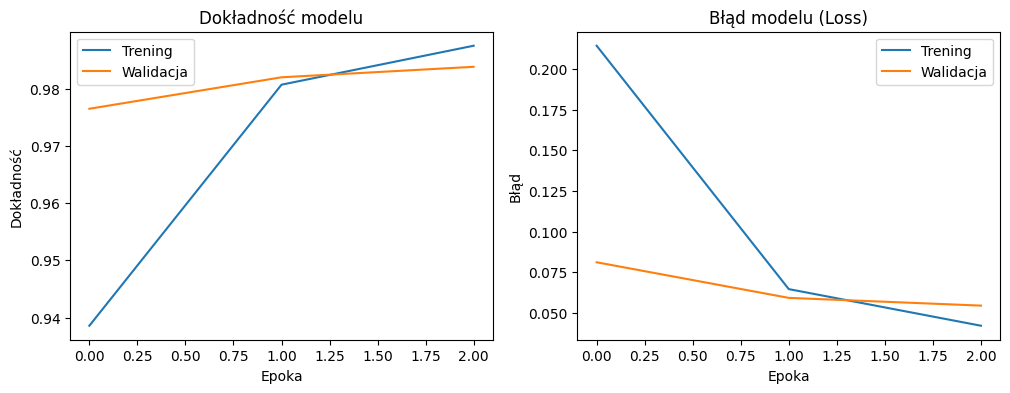

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


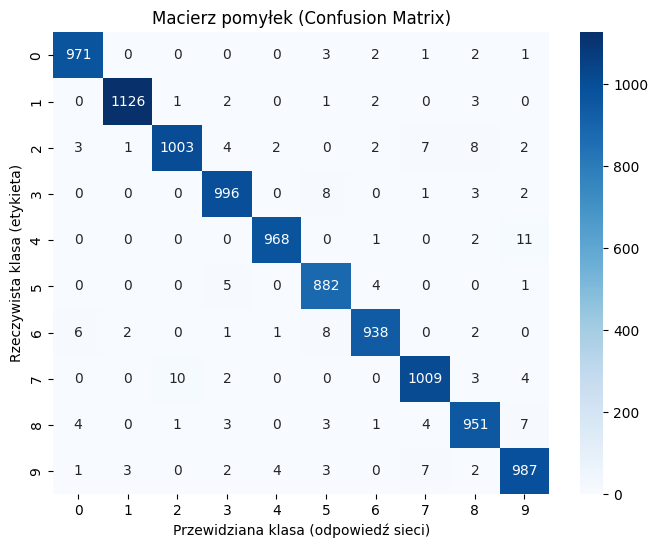

In [12]:
# Krzywe zbieżności
plt.figure(figsize=(12, 4))

# Wykres dokładności (accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Trening')
plt.plot(history.history['val_accuracy'], label='Walidacja')
plt.title('Dokładność modelu')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend()

# Wykres funkcji straty
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Trening')
plt.plot(history.history['val_loss'], label='Walidacja')
plt.title('Błąd modelu (Loss)')
plt.xlabel('Epoka')
plt.ylabel('Błąd')
plt.legend()

plt.show()

x_test_cnn = x_test.reshape(-1, 28, 28, 1)

#Macierz pomyłek

predictions = model.predict(x_test_cnn)
pred_labels = predictions.argmax(axis=1)
cm = tf.math.confusion_matrix(y_test, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Przewidziana klasa (odpowiedź sieci)')
plt.ylabel('Rzeczywista klasa (etykieta)')
plt.title('Macierz pomyłek (Confusion Matrix)')
plt.show()

**1. Analiza krzywych zbieżności (Accuracy i Loss)**
Wykresy dokładności oraz błędu modelu wskazują na bardzo stabilny i prawidłowy przebieg procesu optymalizacji sieci.

* **Brak przeuczenia (overfittingu):** Krzywe dla zbioru treningowego i walidacyjnego podążają w tym samym kierunku. Dokładność na zbiorze walidacyjnym rośnie, a funkcja straty maleje, nie wykazując tendencji do rozbieżności. Oznacza to, że model świetnie generalizuje wiedzę na nowe, niewidziane wcześniej dane.
* **Szybka zbieżność:** Znaczny spadek błędu treningowego już po pierwszej epoce świadczy o tym, że zastosowana architektura (w tym odpowiednio dobrane filtry splotowe) pozwala na błyskawiczne wychwycenie kluczowych cech z obrazów zbioru MNIST.

**2. Analiza macierzy pomyłek (Confusion Matrix)**
Macierz pomyłek stanowi doskonałe potwierdzenie wysokiej skuteczności klasyfikatora – zdecydowana większość predykcji skupia się na głównej przekątnej (wartości rzędu 900–1100 poprawnych trafień dla poszczególnych klas). Analiza nielicznych błędów (wartości poza przekątną) dostarcza jednak cennych wniosków na temat natury danych:

* Model nie myli się w sposób losowy. Błędy wynikają bezpośrednio z wizualnego podobieństwa poszczególnych, odręcznie pisanych cyfr.
* **Najczęstsze pomyłki:**
* **"4" mylone z "9":** Prawdziwa cyfra "4" została 11 razy sklasyfikowana jako "9".
* **"7" mylone z "2":** Rzeczywista cyfra "7" została 10 razy zaklasyfikowana jako "2". Wynika to najpewniej ze specyficznego stylu pisania "siódemki" z poziomą kreską pośrodku oraz zawijasem na dole, co upodabnia ją do "dwójki".
* Prawdziwa **"2"** była również mylona z **"8"** (8 przypadków) oraz z **"7"** (7 przypadków).

## Zadanie 5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


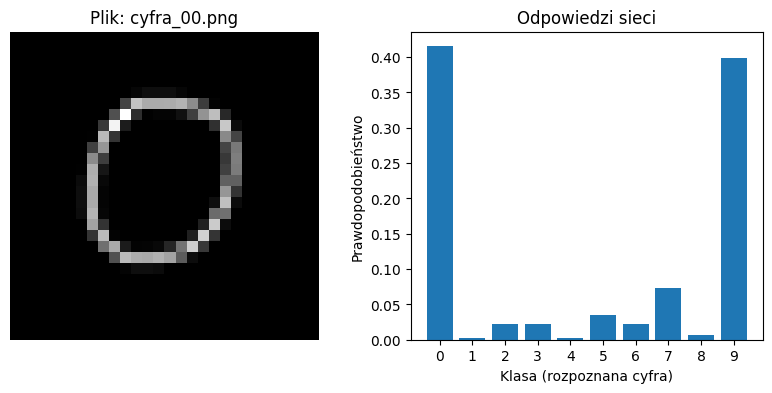

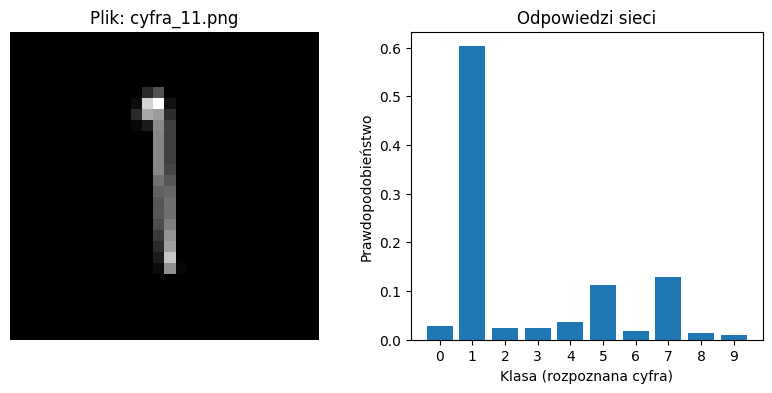

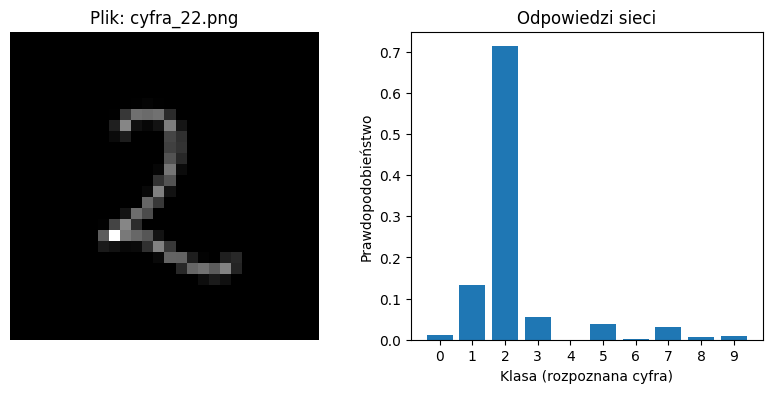

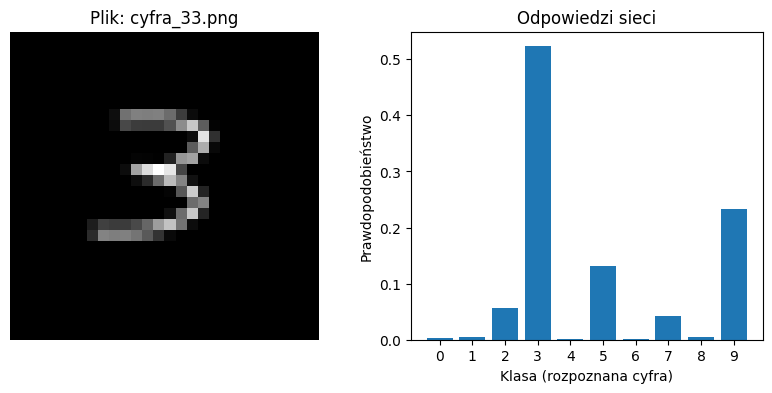

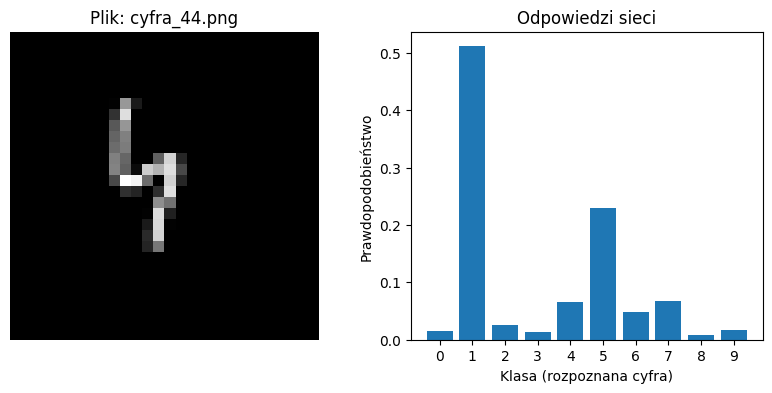

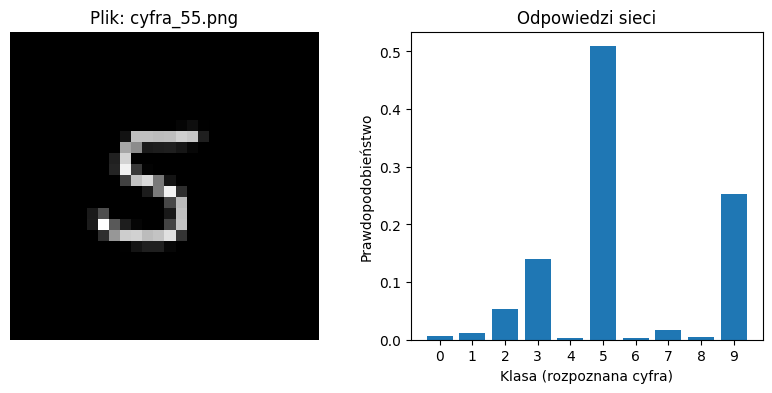

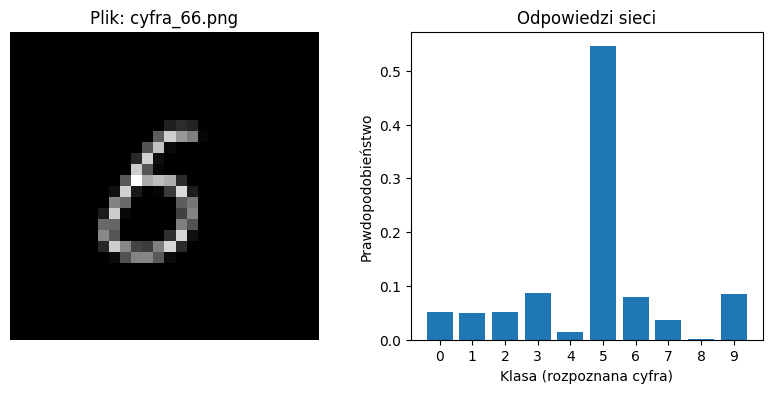

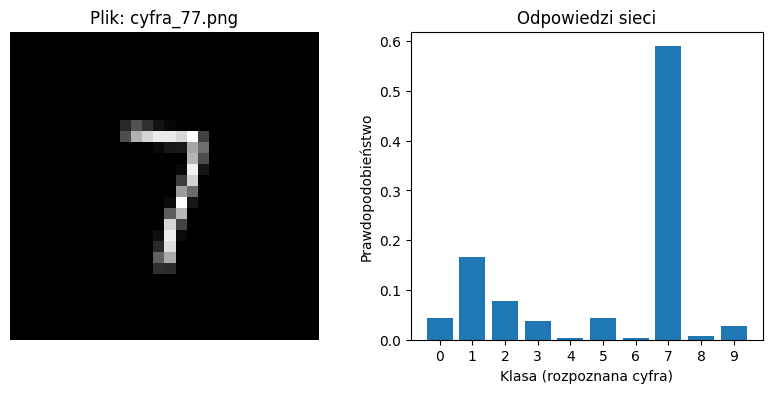

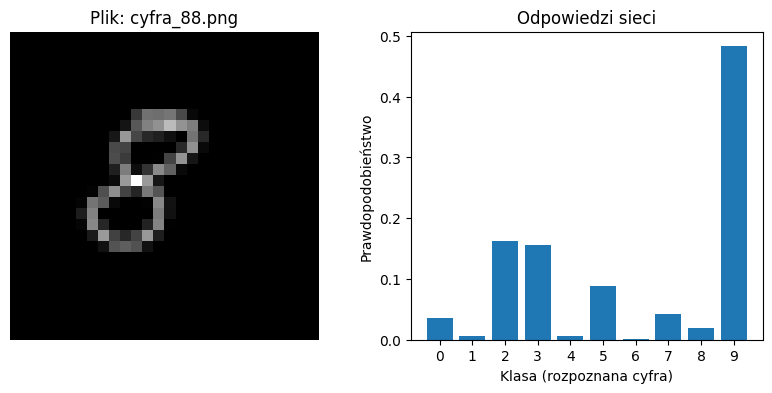

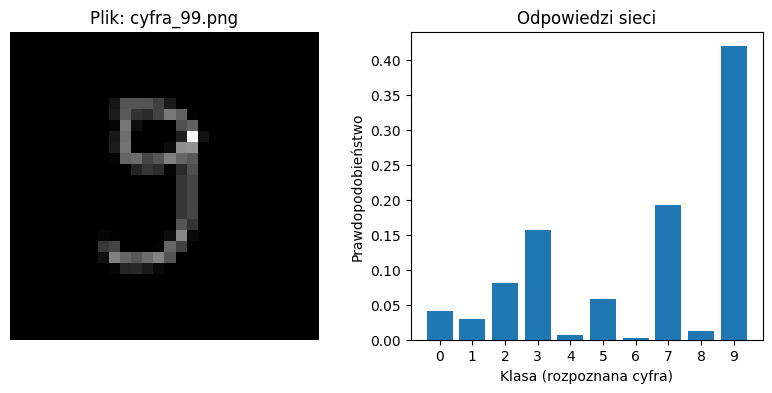

In [17]:
pliki_cyfry = ['cyfra_00.png', 'cyfra_11.png', 'cyfra_22.png', 'cyfra_33.png', 'cyfra_44.png', 'cyfra_55.png', 'cyfra_66.png', 'cyfra_77.png', 'cyfra_88.png', 'cyfra_99.png']
liczba_obrazow = len(pliki_cyfry)
macierz_obrazow = np.empty([liczba_obrazow, 28, 28])

for i in range(liczba_obrazow):
    obraz = cv2.imread(pliki_cyfry[i],0)
    obraz = 255 - obraz
    macierz_obrazow[i] = obraz / 255.0

macierz_obrazow_cnn = macierz_obrazow.reshape(-1, 28, 28, 1)
odpowiedzi_modelu = model.predict(macierz_obrazow_cnn)

for i in range(liczba_obrazow):
    plt.figure(figsize=(10,4))

    plt.subplot(1, 2, 1)
    plt.imshow(macierz_obrazow[i], cmap='gray')
    plt.title(f"Plik: {pliki_cyfry[i]}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.bar(range(10),odpowiedzi_modelu[i])
    plt.title('Odpowiedzi sieci')
    plt.xlabel('Klasa (rozpoznana cyfra)')
    plt.ylabel('Prawdopodobieństwo')
    plt.xticks([0,1,2,3,4,5,6,7,8,9])
    plt.show()

## Zadanie dodatkowe (1)

In [18]:
# Budujemy klasyczny model MLP
model_mlp = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

# Kompilacja modelu
model_mlp.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("Trenowanie sieci MLP")

history_mlp = model_mlp.fit(x_train, y_train,
                            epochs=5,
                            batch_size=64,
                            validation_split=0.2)

Trenowanie sieci MLP
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9087 - loss: 0.3169 - val_accuracy: 0.9553 - val_loss: 0.1507
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9600 - loss: 0.1333 - val_accuracy: 0.9659 - val_loss: 0.1120
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9727 - loss: 0.0916 - val_accuracy: 0.9711 - val_loss: 0.1012
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9800 - loss: 0.0670 - val_accuracy: 0.9716 - val_loss: 0.0984
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9859 - loss: 0.0499 - val_accuracy: 0.9714 - val_loss: 0.0977


**Wysoka skuteczność bazowa:** Podobnie jak w przypadku modeli konwolucyjnych, sieć MLP w bardzo krótkim czasie osiąga wysoką dokładność na zbiorze walidacyjnym (ponad 97%). Potwierdza to, że zbiór danych MNIST jest stosunkowo łatwy do modelowania, a wyraźne kontury cyfr pozwalają na skuteczną klasyfikację nawet przy użyciu klasycznych architektur.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


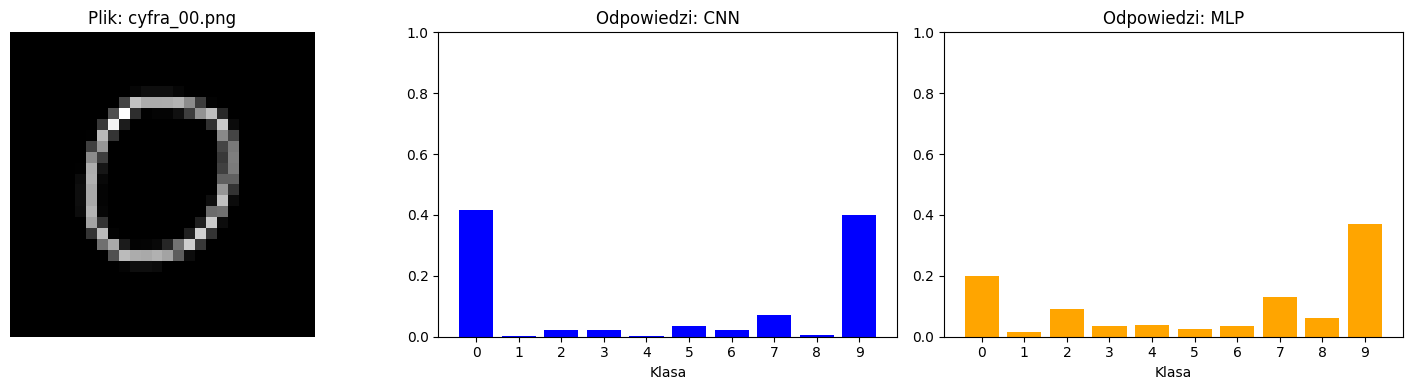

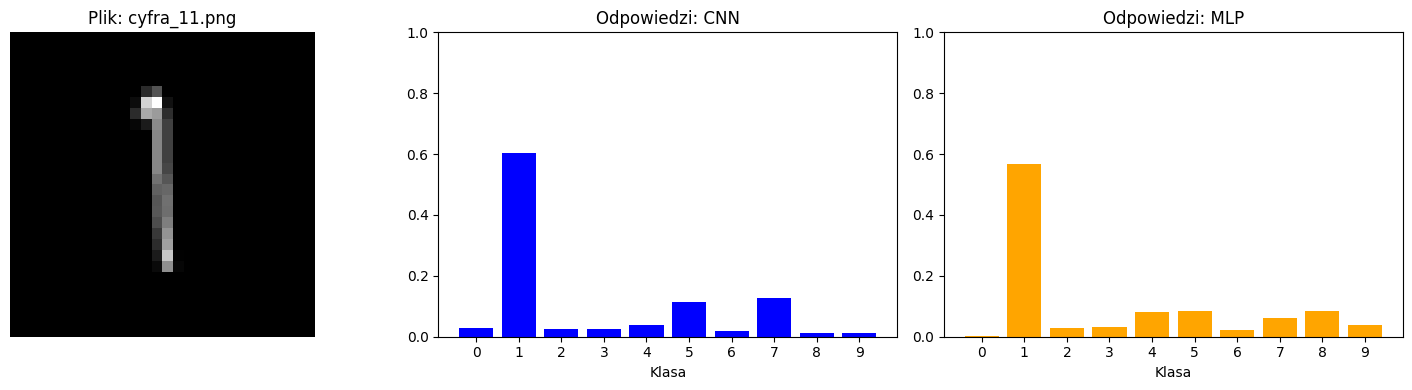

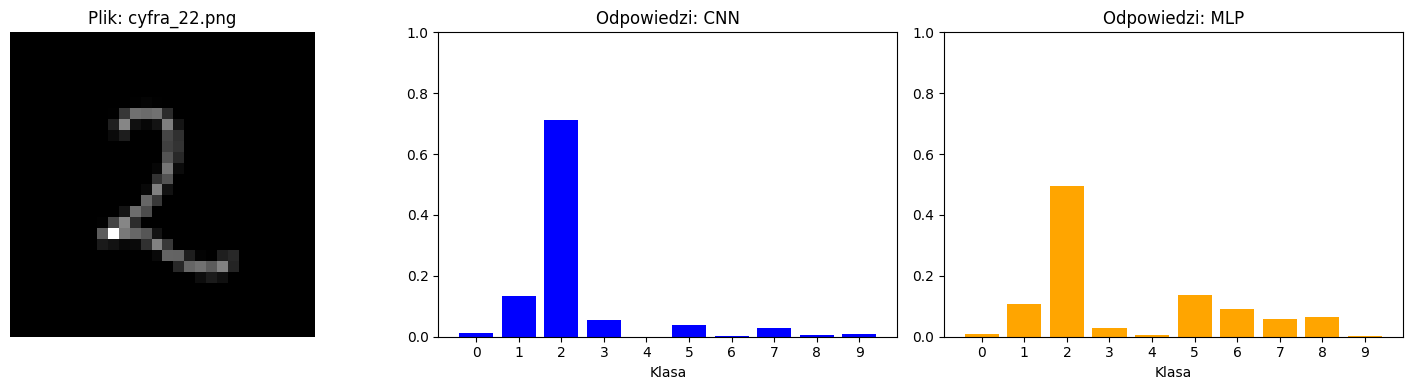

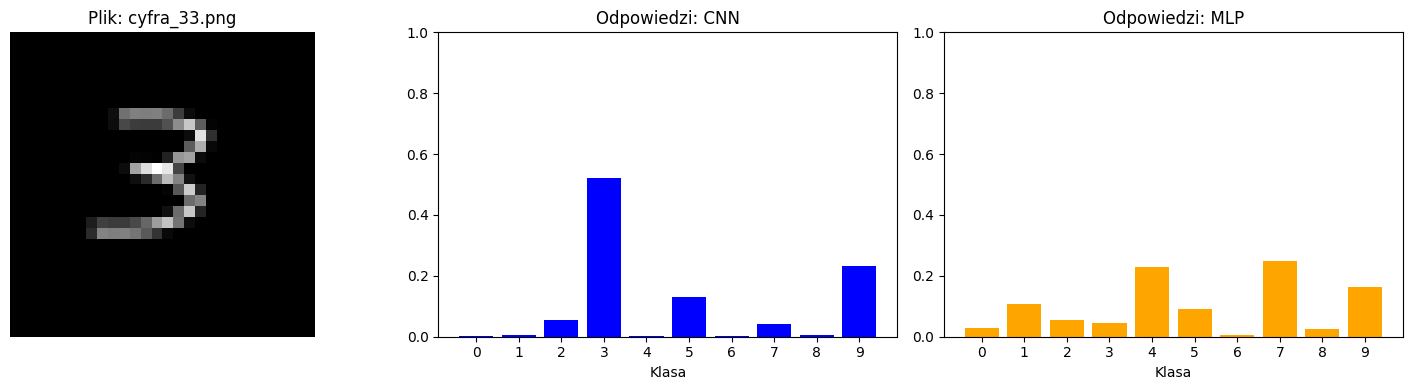

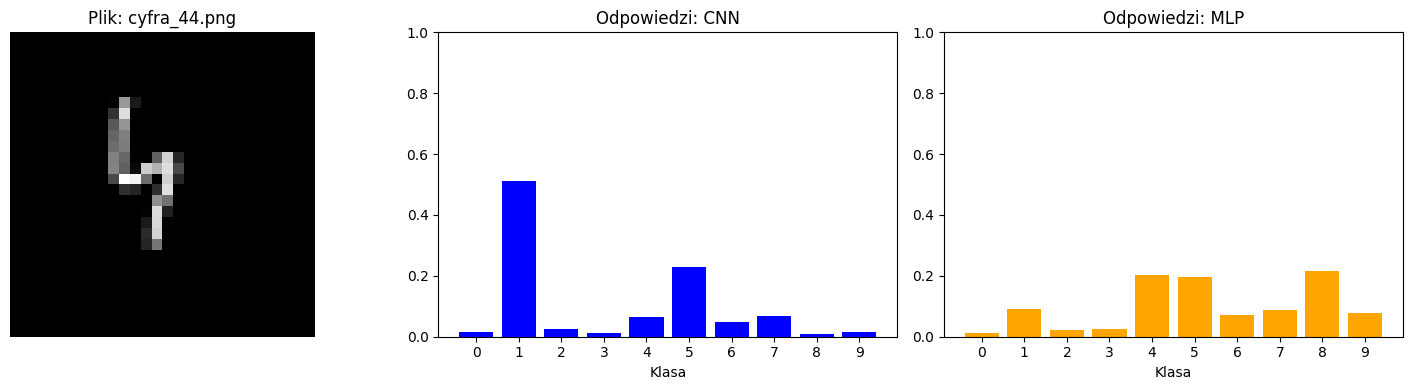

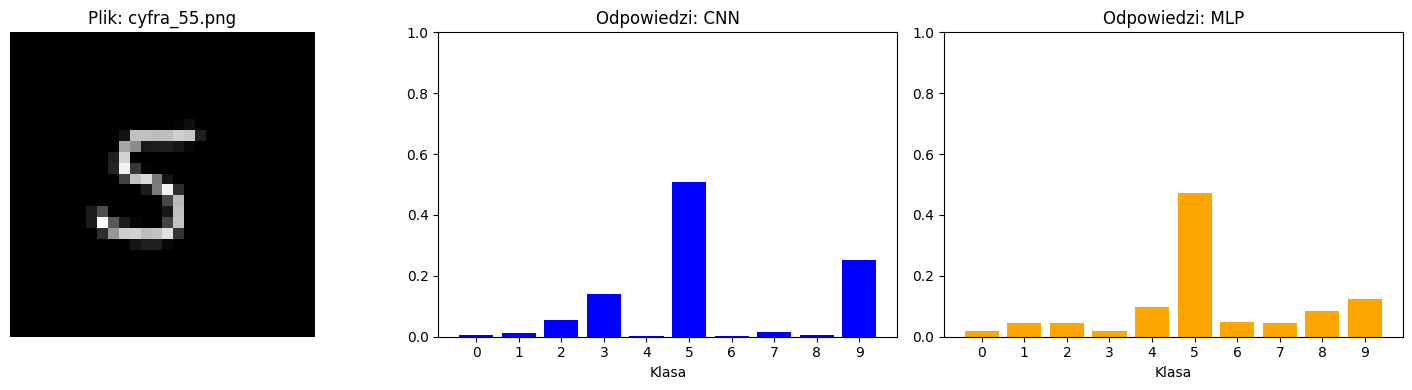

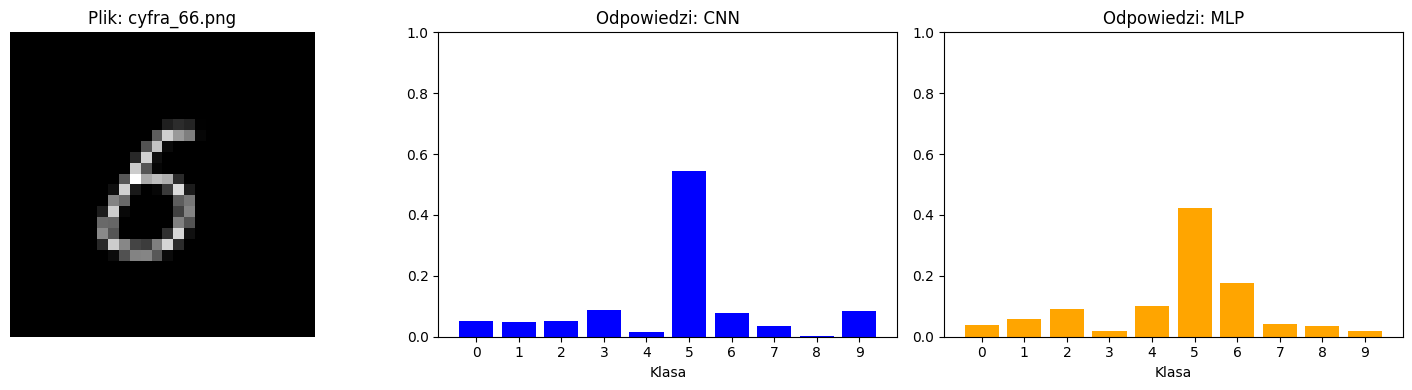

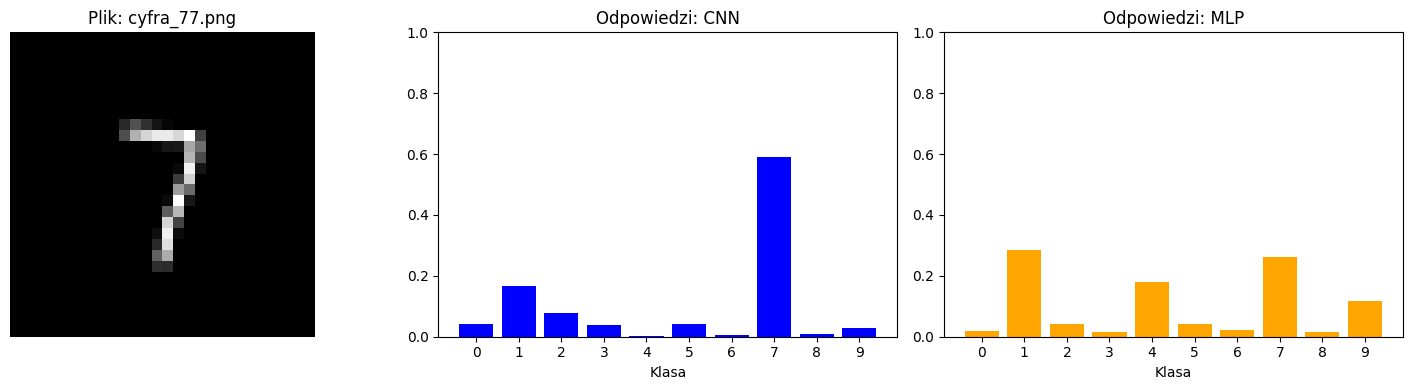

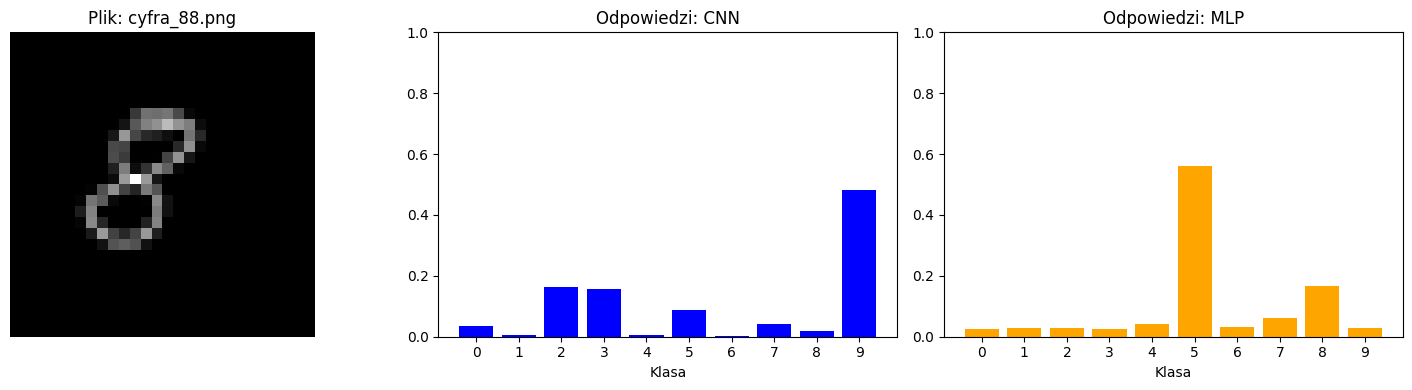

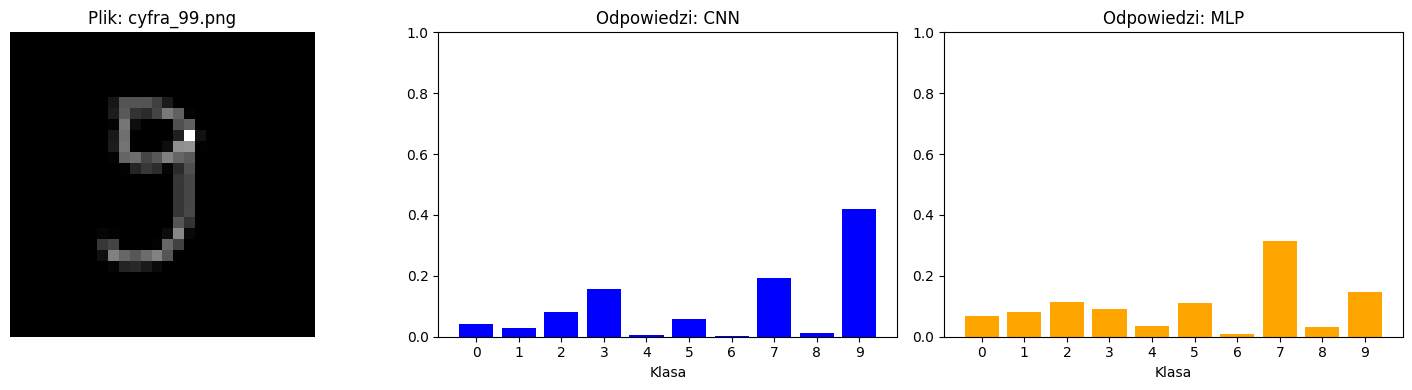


===== PODSUMOWANIE =====
cyfra_00.png:
  CNN → cyfra 0 z prawdopodobieństwem 0.42
  MLP → cyfra 9 z prawdopodobieństwem 0.37
cyfra_11.png:
  CNN → cyfra 1 z prawdopodobieństwem 0.60
  MLP → cyfra 1 z prawdopodobieństwem 0.57
cyfra_22.png:
  CNN → cyfra 2 z prawdopodobieństwem 0.71
  MLP → cyfra 2 z prawdopodobieństwem 0.50
cyfra_33.png:
  CNN → cyfra 3 z prawdopodobieństwem 0.52
  MLP → cyfra 7 z prawdopodobieństwem 0.25
cyfra_44.png:
  CNN → cyfra 1 z prawdopodobieństwem 0.51
  MLP → cyfra 8 z prawdopodobieństwem 0.22
cyfra_55.png:
  CNN → cyfra 5 z prawdopodobieństwem 0.51
  MLP → cyfra 5 z prawdopodobieństwem 0.47
cyfra_66.png:
  CNN → cyfra 5 z prawdopodobieństwem 0.55
  MLP → cyfra 5 z prawdopodobieństwem 0.42
cyfra_77.png:
  CNN → cyfra 7 z prawdopodobieństwem 0.59
  MLP → cyfra 1 z prawdopodobieństwem 0.29
cyfra_88.png:
  CNN → cyfra 9 z prawdopodobieństwem 0.48
  MLP → cyfra 5 z prawdopodobieństwem 0.56
cyfra_99.png:
  CNN → cyfra 9 z prawdopodobieństwem 0.42
  MLP → cyfra 7 z

In [23]:
pliki_cyfry = ['cyfra_00.png', 'cyfra_11.png', 'cyfra_22.png', 'cyfra_33.png', 'cyfra_44.png', 'cyfra_55.png', 'cyfra_66.png', 'cyfra_77.png', 'cyfra_88.png', 'cyfra_99.png']
liczba_obrazow = len(pliki_cyfry)
macierz_obrazow = np.empty([liczba_obrazow, 28, 28])

for i in range(liczba_obrazow):
    obraz = cv2.imread(pliki_cyfry[i], 0)
    obraz = 255 - obraz
    macierz_obrazow[i] = obraz / 255.0

macierz_obrazow_cnn = macierz_obrazow.reshape(-1, 28, 28, 1)
odpowiedzi_cnn = model.predict(macierz_obrazow_cnn)

odpowiedzi_mlp = model_mlp.predict(macierz_obrazow)

# Wyświetlanie porównania
for i in range(liczba_obrazow):
    plt.figure(figsize=(15, 4))

    # Oryginalny obrazek
    plt.subplot(1, 3, 1)
    plt.imshow(macierz_obrazow[i], cmap='gray')
    plt.title(f"Plik: {pliki_cyfry[i]}")
    plt.axis('off')

    # Wykres dla CNN
    plt.subplot(1, 3, 2)
    plt.bar(range(10), odpowiedzi_cnn[i], color='blue')
    plt.title('Odpowiedzi: CNN')
    plt.xlabel('Klasa')
    plt.xticks(range(10))
    plt.ylim([0, 1])

    # Wykres dla MLP
    plt.subplot(1, 3, 3)
    plt.bar(range(10), odpowiedzi_mlp[i], color='orange')
    plt.title('Odpowiedzi: MLP')
    plt.xlabel('Klasa')
    plt.xticks(range(10))
    plt.ylim([0, 1])

    plt.tight_layout()
    plt.show()

print("\n===== PODSUMOWANIE =====")
for i in range(liczba_obrazow):
    cnn_cyfra = odpowiedzi_cnn[i].argmax()
    cnn_pewnosc = odpowiedzi_cnn[i].max()
    mlp_cyfra = odpowiedzi_mlp[i].argmax()
    mlp_pewnosc = odpowiedzi_mlp[i].max()

    print(f"{pliki_cyfry[i]}:")
    print(f"  CNN → cyfra {cnn_cyfra} z prawdopodobieństwem {cnn_pewnosc:.2f}")
    print(f"  MLP → cyfra {mlp_cyfra} z prawdopodobieństwem {mlp_pewnosc:.2f}")

**1. Zdolność do generalizacji**
Dane testowe bezlitośnie obnażyły słabości klasycznej architektury MLP. Model konwolucyjny (CNN) sklasyfikował poprawnie 7 z 10 cyfr. Z kolei model MLP poradził sobie zaledwie w 3 przypadkach (cyfry 1, 2 i 5).
Spłaszczenie obrazu (Flatten) na wczesnym etapie w MLP niszczy relacje przestrzenne między pikselami. CNN, dzięki filtrom splotowym przesuwanym po obrazie, wykrywa lokalne cechy niezależnie od ich dokładnego położenia czy grubości linii, co skutkuje drastycznie wyższą skutecznością na danych spoza zbioru treningowego MNIST.

**2. Logika i natura pomyłek**
Błędy popełniane przez oba modele mają zupełnie inny charakter, co doskonale obrazuje różnicę w ich "sposobie widzenia":

* **CNN zachowuje "logikę wizualną":** Pomyłki CNN wynikają z rzeczywistego, morfologicznego podobieństwa znaków. Pomyłka cyfry 8 z 9 (prawd. 0.48), 6 z 5 (prawd. 0.55), czy 4 z 1 (prawd. 0.51) wynika z obecności silnych wspólnych cech (podobne pętle, brzuszki lub proste, pionowe linie). Sieć splotowa wykryła cechy, które faktycznie mogą należeć do obu klas.
* **MLP działa losowo poza dystrybucją:** Błędy MLP wydają się z perspektywy człowieka całkowicie nielogiczne. Klasyfikowanie zera jako 9, trójki jako 7, czwórki jako 8, czy siódemki jako 1 wynika z faktu, że MLP traktuje obraz jak sztywny wektor. Wystarczy, że odręczna cyfra jest przesunięta, aby aktywowały się zupełnie inne "piksele" niż te, do których MLP przyzwyczaił się podczas treningu na idealnie wycentrowanym zbiorze MNIST.

**3. Kalibracja pewności (Analiza prawdopodobieństw Softmax)**
Zwracane wartości prawdopodobieństw precyzyjnie pokazują stan pewności modeli:

* **Kompletna dezorientacja MLP:** W przypadku błędnych predykcji, sieć MLP zwraca wyjątkowo niskie prawdopodobieństwa (np. 0.25 dla cyfry 3, 0.22 dla cyfry 4, 0.29 dla cyfry 7, 0.32 dla cyfry 9). Świadczy to o tym, że podany obraz jest dla niej kompletnym szumem – nie pasuje do żadnego wyuczonego "szablonu", a model de facto zgaduje, wybierając klasę z marginalną przewagą.
* **Stabilna analiza CNN:** Sieć konwolucyjna działa znacznie pewniej. Nawet w przypadkach pomyłki zwraca umiarkowanie wysokie prawdopodobieństwa (ok. 0.48 - 0.55). Pokazuje to, że CNN *znalazł* na obrazie konkretne cechy wysokopoziomowe i świadomie podjął decyzję o ich klasyfikacji, a nie po prostu "zawrzucił" losowy wynik.


# D. Podsumowanie i wnioski końcowe

1. **Przewaga analizy przestrzennej:** Sieci konwolucyjne (CNN) są bezsprzecznie skuteczniejsze w analizie obrazu niż klasyczne sieci MLP. Wynika to z zastosowania filtrów splotowych, które nie niszczą dwuwymiarowej struktury obrazu, lecz wykrywają lokalne cechy (łuki, krawędzie) niezależnie od ich dokładnego położenia.
2. **Pułapka ustandaryzowanych zbiorów:** Wysokie wyniki na "sterylnym" zbiorze testowym (MNIST) mogą być złudne. Choć oba modele osiągnęły tam dokładność powyżej 97%, sieć MLP dokonała tego głównie poprzez "nauczenie się na pamięć" sztywnych układów pikseli, co szybko doprowadziło do objawów przeuczenia.
3. **Kluczowa rola generalizacji:** Testy na rzeczywistych, autorskich danych bezwzględnie obnażyły kruchość klasycznej architektury. Model MLP całkowicie gubił się przy zmianie stylu pisma, podejmując losowe i nietrafione decyzje. CNN poradził sobie znacznie lepiej, a jego ewentualne pomyłki były logiczne i wynikały z faktycznego morfologicznego podobieństwa cyfr.